In [371]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [398]:
def jackson_kernel(moments):
    """
    Apply the Jackson kernel to Chebyshev moments.

    Parameters
    ----------
    moments : array-like
        1D array of Chebyshev moments mu_n, n = 0, ..., M-1.

    Returns
    -------
    np.ndarray
        Jackson-damped moments.
    """
    moments = np.asarray(moments, dtype=float)
    M = moments.size

    if M == 0:
        raise ValueError("moments must be non-empty")

    n = np.arange(M, dtype=float)
    alpha = np.pi / (M + 1)
    cot_alpha = 1.0 / np.tan(alpha)

    g = (
        (M - n + 1) * np.cos(alpha * n)
        + np.sin(alpha * n) * cot_alpha
    ) / (M + 1)

    return g * moments

def kpm_approx(moments, grid, f_pols=1, jackson=True):
    f_moments = moments[: int(len(moments) * f_pols)]
    theta = np.arccos(grid)                      # shape (Nx,)
    n = np.arange(len(f_moments))[:, None]      # shape (Nm, 1)

    T = np.cos(n * theta)                     # shape (Nm, Nx)

    if jackson:
        coeffs = jackson_kernel(f_moments)
    else:
        coeffs = f_moments.copy()

    coeffs[1:] *= 2.0

    f = np.sum(coeffs[:, None] * T, axis=0)
    f /= (np.pi * np.sqrt(1.0 - grid**2))

    return f

In [424]:
E = np.linspace(-0.99, 0.99, 400)
D = kpm_approx(np.asarray(pd.read_csv("data/dos-1024x1024-1_L-yopen.txt")["mu"]), E, 1, True)

(-4.0, -3.0)

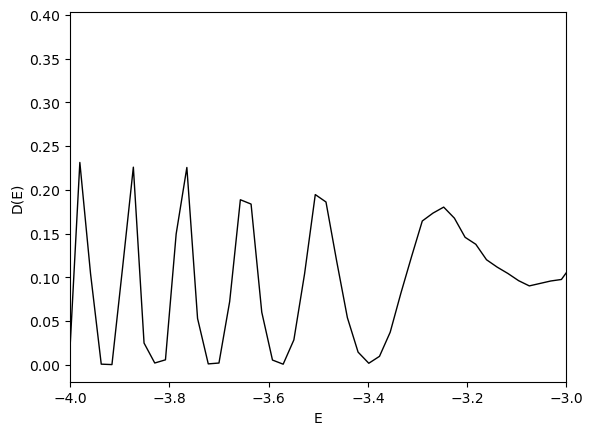

In [426]:
plt.plot(E / 0.23, D * 0.23, linewidth=1, color="black")
plt.xlabel("E")
plt.ylabel("D(E)")
plt.xlim(-4,-3)